# Block2 Stress — Response Curves

Encoder (moiraie) vs Decoder (moiraic) on all stress-test families.

**Structure per family:**
- Panel A: sample series (context + shaded horizon)
- Panel B: sample forecasts (encoder=blue, decoder=orange, q10–q90 shaded)
- Panel C: response curve (aggregated metric per level, sigmoid fit, CIs)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../..'))

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from experiments.mech_interp.block2_stress import load_stress_dataset
from experiments.mech_interp.block2_stress.run_forecasts import run_family, load_forecasts
from experiments.mech_interp.block2_stress import metrics as M
from experiments.mech_interp.block2_stress.curves import (
    fit_sigmoid, bootstrap_sigmoid, plot_response_curve, make_summary_csv
)
from experiments.mech_interp.lib.utils import _load_module

# ── Config ──────────────────────────────────────────────────────────────────
DATA_DIR     = str(Path('../data/stress').resolve())
FORECAST_DIR = str(Path('../data/forecasts').resolve())
SUMMARY_DIR  = str(Path('../results/curves').resolve())

MOIRAIE_CKPT = '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last'
MOIRAIC_CKPT = '/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last'

DEVICE     = 'cuda:7'   # change to 'cuda:7' for GPU
BATCH_SIZE = 32
N_SAMPLES  = 4       # series to show in panels A and B
SEED       = 0

# Load config from index
idx = np.load(os.path.join(DATA_DIR, 'index.npz'), allow_pickle=True)
cfg = json.loads(str(idx['config_json'][0]))
CTX = cfg['context_patches'] * cfg['patch_len']   # 256
HOR = cfg['horizon_patches'] * cfg['patch_len']   # 64
T   = CTX + HOR                                   # 320
Q_LEVELS = cfg.get('quantile_levels', [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
MED_IDX = len(Q_LEVELS) // 2   # index 4 → q=0.5
DEC_COLOR = '#1f77b4'
ENC_COLOR  = '#ff7f0e'

rng = np.random.default_rng(SEED)

print(f'CTX={CTX}, HOR={HOR}, T={T}')
print(f'Quantile levels: {Q_LEVELS}')

CTX=256, HOR=64, T=320
Quantile levels: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [2]:
# ── Load models ─────────────────────────────────────────────────────────────
print('Loading moiraie ...')
enc_module = _load_module(MOIRAIE_CKPT, 'moiraie', DEVICE)
print('Loading moiraic ...')
dec_module = _load_module(MOIRAIC_CKPT, 'moiraic', DEVICE)
print('Done.')

Loading moiraie ...
  Loading moiraie from /srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last (device=cuda:7)
Loading weights from local directory
Loading moiraic ...
  Loading moiraic from /srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last (device=cuda:7)
Loading weights from local directory
Done.


In [3]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def sample_idxs(n_total, n=N_SAMPLES):
    return rng.choice(n_total, size=min(n, n_total), replace=False)

def get_forecasts(family, level_key):
    """Load from disk if saved, otherwise run on-the-fly."""
    enc_path = os.path.join(FORECAST_DIR, 'moiraie', family, f'{level_key}.npz')
    dec_path = os.path.join(FORECAST_DIR, 'moiraic', family, f'{level_key}.npz')
    if os.path.exists(enc_path) and os.path.exists(dec_path):
        return load_forecasts(FORECAST_DIR, 'moiraie', family, level_key), \
               load_forecasts(FORECAST_DIR, 'moiraic', family, level_key)
    enc_res = run_family(enc_module, family, level_key, DATA_DIR, cfg, BATCH_SIZE, DEVICE)
    dec_res = run_family(dec_module, family, level_key, DATA_DIR, cfg, BATCH_SIZE, DEVICE)
    return enc_res, dec_res

def plot_series_panel(axes_row, series, enc_res=None, dec_res=None, si_list=None, meta_label='', ctx=CTX):
    """Panel A: sample series grid."""
    for col, ax in enumerate(axes_row):
        ax.axvspan(ctx, T, alpha=0.08, color='orange')
        ax.axvline(ctx, color='gray', lw=0.8, ls='--')
        ax.plot(series[col], color='black', lw=0.8, label='truth')
        if enc_res is not None:
            # encoder
            h = np.arange(series[col].shape[0]-ctx) + ctx
            enc_q = enc_res['forecast_quantiles'][si_list[col]]   # [9, H]
            ax.fill_between(h, enc_q[0], enc_q[-1], alpha=0.15, color=ENC_COLOR)
            ax.plot(h, enc_q[MED_IDX], color=ENC_COLOR, lw=1.0, label='encoder')
        if dec_res is not None:
            # decoder
            dec_q = dec_res['forecast_quantiles'][si_list[col]]   # [9, H]
            h = np.arange(series[col].shape[0]-ctx) + ctx
            ax.fill_between(h, dec_q[0], dec_q[-1], alpha=0.15, color=DEC_COLOR)
            ax.plot(h, dec_q[MED_IDX], color=DEC_COLOR, lw=1.0, label='decoder')
        ax.set_title(f'sample {col}' if col > 0 else meta_label, fontsize=8)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.legend(fontsize=6)

def plot_forecast_panel(axes_row, series, enc_res, dec_res, si_list, ctx=CTX):
    """Panel B: sample forecasts with q10-q90 shading."""
    h = np.arange(HOR)
    for col, si in enumerate(si_list):
        ax = axes_row[col]
        ax.axvline(0, color='gray', lw=0.8, ls='--')
        # ground truth
        ax.plot(h, enc_res['target'][si], color='black', lw=1.0, ls='--', label='truth')
        # encoder
        enc_q = enc_res['forecast_quantiles'][si]   # [9, H]
        ax.fill_between(h, enc_q[0], enc_q[-1], alpha=0.15, color=ENC_COLOR)
        ax.plot(h, enc_q[MED_IDX], color=ENC_COLOR, lw=1.0, label='encoder')
        # decoder
        dec_q = dec_res['forecast_quantiles'][si]   # [9, H]
        ax.fill_between(h, dec_q[0], dec_q[-1], alpha=0.15, color=DEC_COLOR)
        ax.plot(h, dec_q[MED_IDX], color=DEC_COLOR, lw=1.0, label='decoder')
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.legend(fontsize=6)

summary_rows = []  # collect for CSV

---
## Family A — Periodic carrier (SNR sweep)

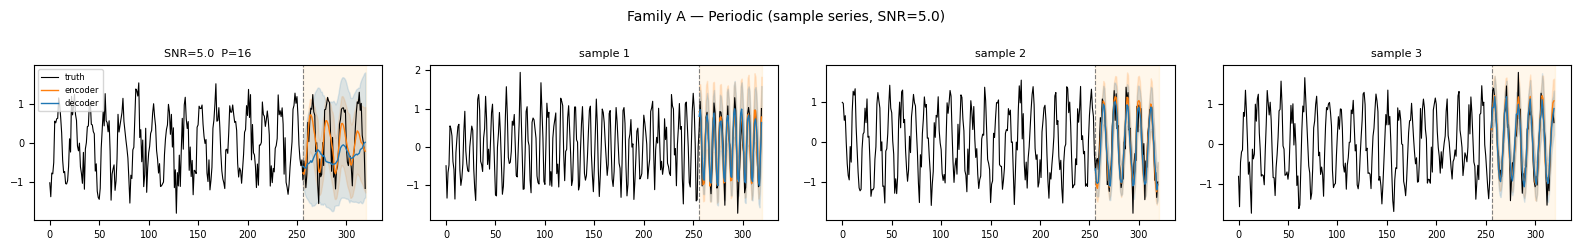

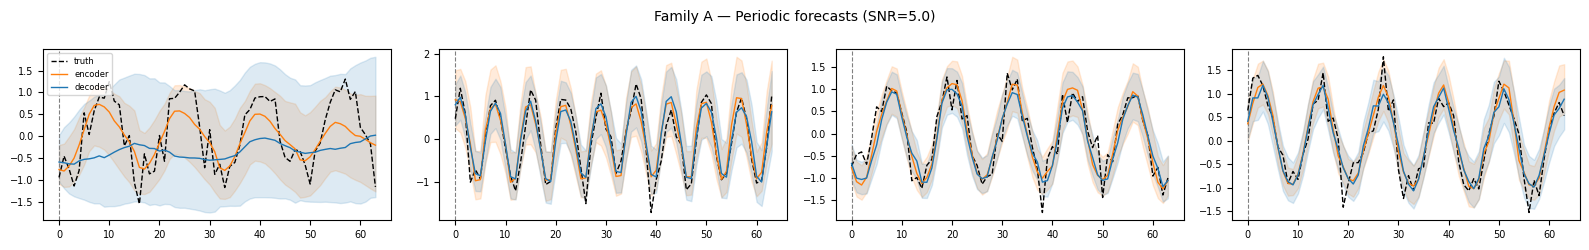

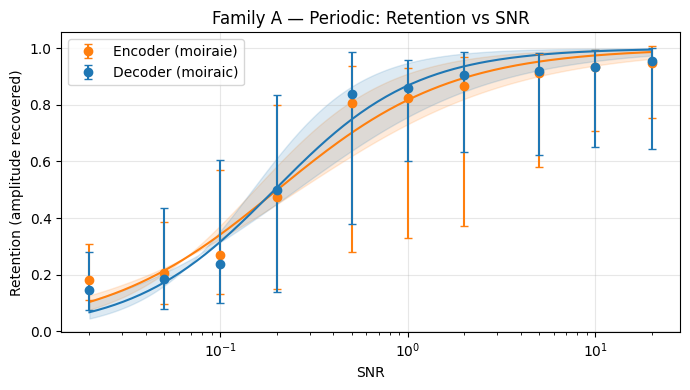

enc x_star=0.201  beta=0.934  r2=0.969
dec x_star=0.194  beta=1.153  r2=0.972


In [4]:
snr_levels = cfg['family_a']['snr_levels'] # [20.0, 10.0, 5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
family = 'family_a_periodic'

snr_plot = 5.0

enc_scores_all, dec_scores_all = [], []
sample_enc, sample_dec, sample_series, sample_meta = None, None, None, None

for li, snr in enumerate(snr_levels):
    level_key = f'snr_{li:02d}'
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res, dec_res = get_forecasts(family, level_key)

    enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
    dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

    enc_scores_all.append(M.retention_periodic(enc_med, meta, cfg))
    dec_scores_all.append(M.retention_periodic(dec_med, meta, cfg))

    if snr == snr_plot:
        si_list = sample_idxs(len(series))
        sample_series = series[si_list]
        sample_meta = {k: v[si_list] for k, v in meta.items()}
        sample_enc, sample_dec = enc_res, dec_res
        sample_si_list = si_list
        sample_snr = snr

# ── Panel A: sample series ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family A — Periodic (sample series, SNR={sample_snr})', fontsize=10)
plot_series_panel(axes, sample_series,
                  enc_res=sample_enc, dec_res=sample_dec, si_list=si_list,
                  meta_label=f'SNR={sample_snr:.1f}  P={sample_meta["period_ts"][0]:.0f}')
plt.tight_layout(); plt.show()

# ── Panel B: sample forecasts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family A — Periodic forecasts (SNR={sample_snr})', fontsize=10)
plot_forecast_panel(axes, sample_series, sample_enc, sample_dec, si_list)
plt.tight_layout(); plt.show()

# ── Panel C: response curve ──────────────────────────────────────────────────
enc_meds = np.array([M.aggregate_level(s)[0] for s in enc_scores_all])
dec_meds = np.array([M.aggregate_level(s)[0] for s in dec_scores_all])

enc_fit = bootstrap_sigmoid(np.array(snr_levels), enc_meds)
dec_fit = bootstrap_sigmoid(np.array(snr_levels), dec_meds)

fig = plot_response_curve(
    x_vals=snr_levels,
    encoder_scores=np.array(enc_scores_all),
    decoder_scores=np.array(dec_scores_all),
    encoder_fit=enc_fit, decoder_fit=dec_fit,
    xlabel='SNR', ylabel='Retention (amplitude recovered)',
    title='Family A — Periodic: Retention vs SNR',
    log_x=True,
)
plt.show()

for model_name, fit in [('moiraie', enc_fit), ('moiraic', dec_fit)]:
    summary_rows.append(dict(
        model=model_name, family='family_a_periodic', carrier='periodic',
        x_star=fit['x_star'], x_star_lo=fit['x_star_ci'][0], x_star_hi=fit['x_star_ci'][1],
        beta=fit['beta'], beta_lo=fit['beta_ci'][0], beta_hi=fit['beta_ci'][1],
        r2=fit['r2'],
    ))

print(f"enc x_star={enc_fit['x_star']:.3f}  beta={enc_fit['beta']:.3f}  r2={enc_fit['r2']:.3f}")
print(f"dec x_star={dec_fit['x_star']:.3f}  beta={dec_fit['beta']:.3f}  r2={dec_fit['r2']:.3f}")

---
## Family A — Trend carrier (SNR sweep)

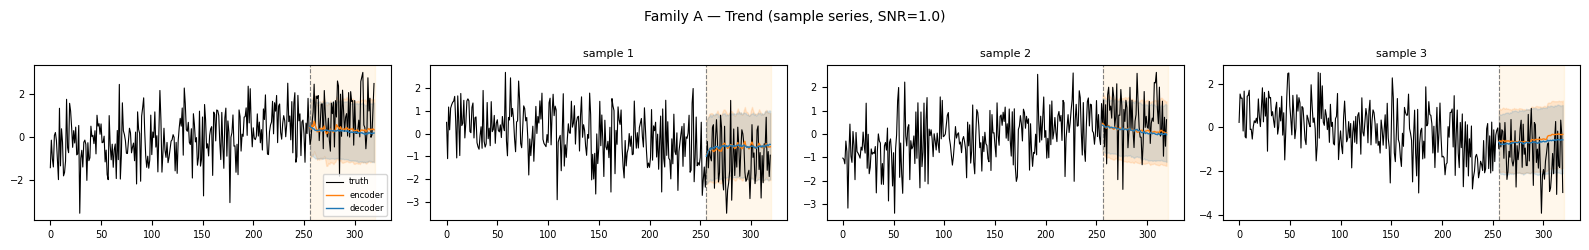

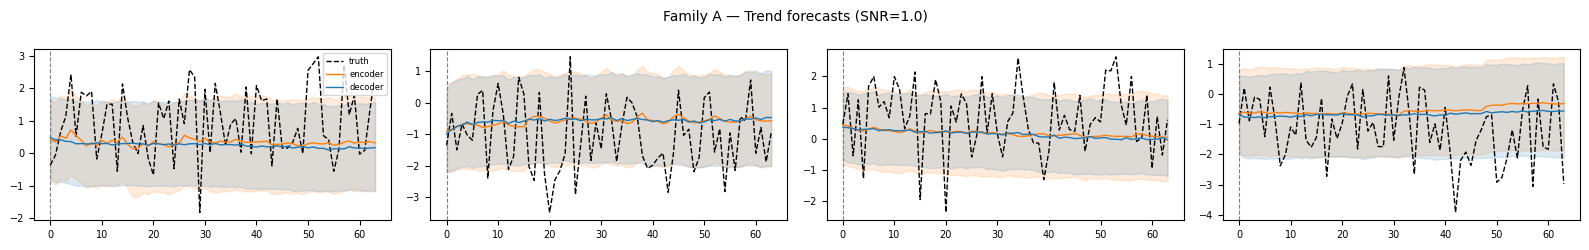

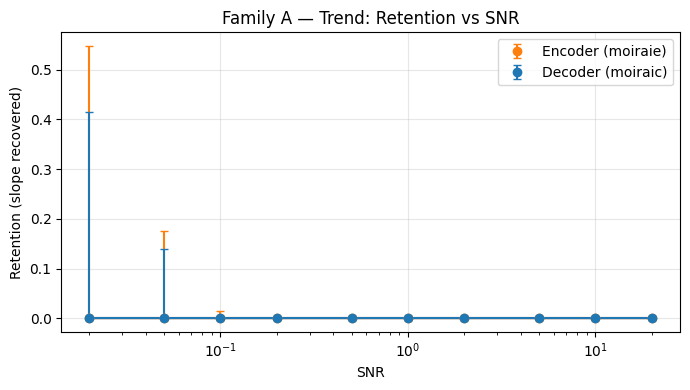

enc x_star=23735.221  beta=1.853  r2=-3.344
dec x_star=23735.221  beta=1.853  r2=-3.344


In [5]:
family = 'family_a_trend'

snr_plot = 1.0 # [20.0, 10.0, 5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05, 0.02]

enc_scores_all, dec_scores_all = [], []

for li, snr in enumerate(snr_levels):
    level_key = f'snr_{li:02d}'
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res, dec_res = get_forecasts(family, level_key)

    enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
    dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

    enc_scores_all.append(M.retention_trend(enc_med, meta, cfg))
    dec_scores_all.append(M.retention_trend(dec_med, meta, cfg))

    if snr == snr_plot:
        si_list = sample_idxs(len(series))
        sample_series = series[si_list]
        sample_enc, sample_dec = enc_res, dec_res
        sample_snr = snr

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family A — Trend (sample series, SNR={sample_snr})', fontsize=10)
plot_series_panel(axes, sample_series,
                  enc_res=sample_enc, dec_res=sample_dec, si_list=si_list)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family A — Trend forecasts (SNR={sample_snr})', fontsize=10)
plot_forecast_panel(axes, sample_series, sample_enc, sample_dec, si_list)
plt.tight_layout(); plt.show()

enc_meds = np.array([M.aggregate_level(s)[0] for s in enc_scores_all])
dec_meds = np.array([M.aggregate_level(s)[0] for s in dec_scores_all])
enc_fit = bootstrap_sigmoid(np.array(snr_levels), enc_meds)
dec_fit = bootstrap_sigmoid(np.array(snr_levels), dec_meds)

fig = plot_response_curve(
    x_vals=snr_levels,
    encoder_scores=np.array(enc_scores_all),
    decoder_scores=np.array(dec_scores_all),
    encoder_fit=enc_fit, decoder_fit=dec_fit,
    xlabel='SNR', ylabel='Retention (slope recovered)',
    title='Family A — Trend: Retention vs SNR',
    log_x=True,
)
plt.show()

for model_name, fit in [('moiraie', enc_fit), ('moiraic', dec_fit)]:
    summary_rows.append(dict(
        model=model_name, family='family_a_trend', carrier='trend',
        x_star=fit['x_star'], x_star_lo=fit['x_star_ci'][0], x_star_hi=fit['x_star_ci'][1],
        beta=fit['beta'], beta_lo=fit['beta_ci'][0], beta_hi=fit['beta_ci'][1],
        r2=fit['r2'],
    ))
print(f"enc x_star={enc_fit['x_star']:.3f}  beta={enc_fit['beta']:.3f}  r2={enc_fit['r2']:.3f}")
print(f"dec x_star={dec_fit['x_star']:.3f}  beta={dec_fit['beta']:.3f}  r2={dec_fit['r2']:.3f}")

---
## Family A — White noise anchor (spectral flatness)

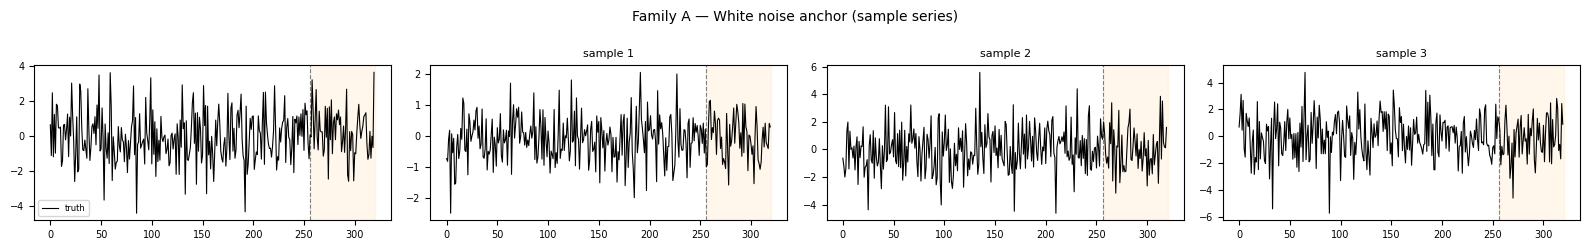

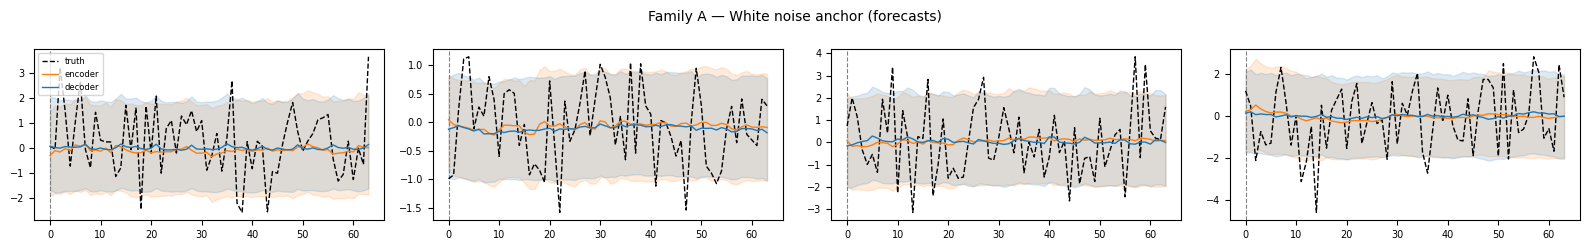

Spectral flatness — encoder: median=0.098  decoder: median=0.083
(~1.0 = white/flat forecast; lower = confabulated structure)


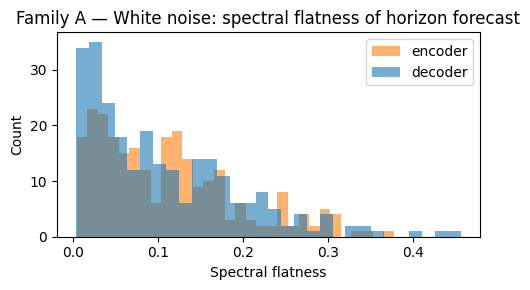

In [6]:
family = 'family_a_white_noise'
level_key = 'anchor'
series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
enc_res, dec_res = get_forecasts(family, level_key)

enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

enc_flat = M.spectral_flatness(enc_med)
dec_flat = M.spectral_flatness(dec_med)

si_list = sample_idxs(len(series))

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle('Family A — White noise anchor (sample series)', fontsize=10)
plot_series_panel(axes, series[si_list])
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle('Family A — White noise anchor (forecasts)', fontsize=10)
plot_forecast_panel(axes, series[si_list], enc_res, dec_res, si_list)
plt.tight_layout(); plt.show()

print(f'Spectral flatness — encoder: median={np.median(enc_flat):.3f}  '
      f'decoder: median={np.median(dec_flat):.3f}')
print('(~1.0 = white/flat forecast; lower = confabulated structure)')

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(enc_flat, bins=30, alpha=0.6, color=ENC_COLOR, label='encoder')
ax.hist(dec_flat, bins=30, alpha=0.6, color=DEC_COLOR, label='decoder')
ax.set_xlabel('Spectral flatness')
ax.set_ylabel('Count')
ax.set_title('Family A — White noise: spectral flatness of horizon forecast')
ax.legend()
plt.tight_layout(); plt.show()

---
## Family B — AR(1) phi sweep (persistence alignment)

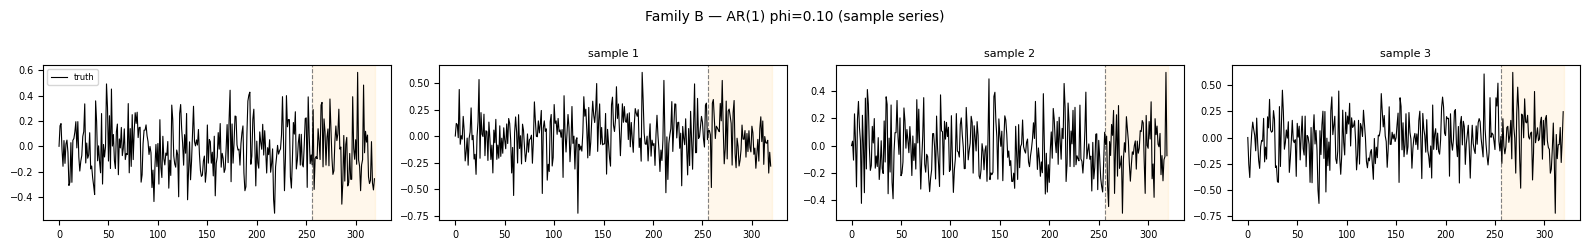

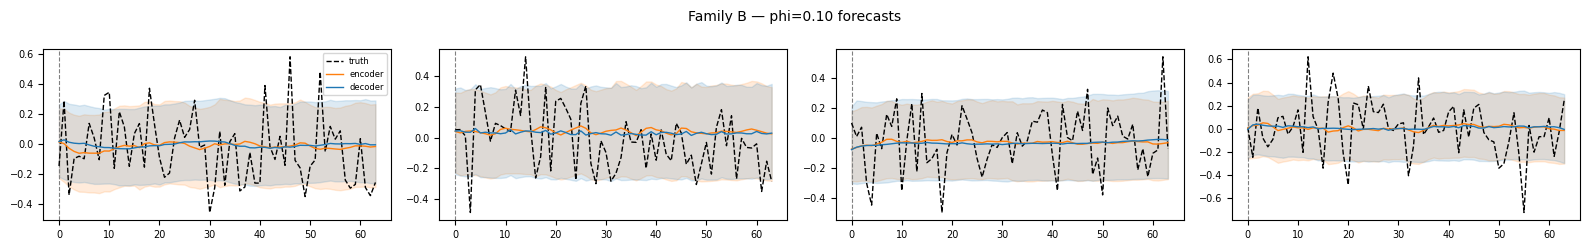

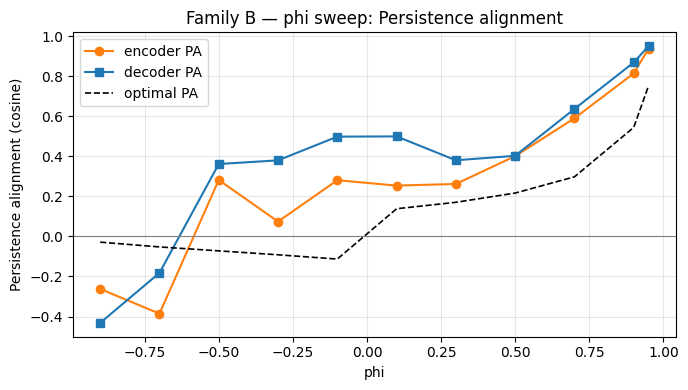

In [7]:
phi_levels = cfg['family_b']['phi_levels'] # [-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95]
family = 'family_b_phi'

phi_plot = 0.1

enc_scores_all, dec_scores_all = [], []
enc_opt_all = []

for li, phi in enumerate(phi_levels):
    level_key = f'phi_{li:02d}'
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res, dec_res = get_forecasts(family, level_key)

    enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
    dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

    enc_scores_all.append(M.persistence_alignment(enc_med, enc_res['context'], cfg))
    dec_scores_all.append(M.persistence_alignment(dec_med, dec_res['context'], cfg))
    enc_opt_all.append(M.optimal_pa(meta, cfg))

    if phi == phi_plot:
        si_list = sample_idxs(len(series))
        sample_series = series[si_list]
        sample_enc, sample_dec = enc_res, dec_res
        sample_phi = phi

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family B — AR(1) phi={sample_phi:.2f} (sample series)', fontsize=10)
plot_series_panel(axes, sample_series)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4, 2.5))
fig.suptitle(f'Family B — phi={sample_phi:.2f} forecasts', fontsize=10)
plot_forecast_panel(axes, sample_series, sample_enc, sample_dec, si_list)
plt.tight_layout(); plt.show()

# Response curve: PA vs phi
enc_meds = np.array([M.aggregate_level(s)[0] for s in enc_scores_all])
dec_meds = np.array([M.aggregate_level(s)[0] for s in dec_scores_all])
opt_meds = np.array([M.aggregate_level(s)[0] for s in enc_opt_all])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(phi_levels, enc_meds, 'o-', color=ENC_COLOR, label='encoder PA')
ax.plot(phi_levels, dec_meds, 's-', color=DEC_COLOR, label='decoder PA')
ax.plot(phi_levels, opt_meds, 'k--', lw=1.2, label='optimal PA')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('phi')
ax.set_ylabel('Persistence alignment (cosine)')
ax.set_title('Family B — phi sweep: Persistence alignment')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Family B — Outlier delta sweep (spike follow ratio)

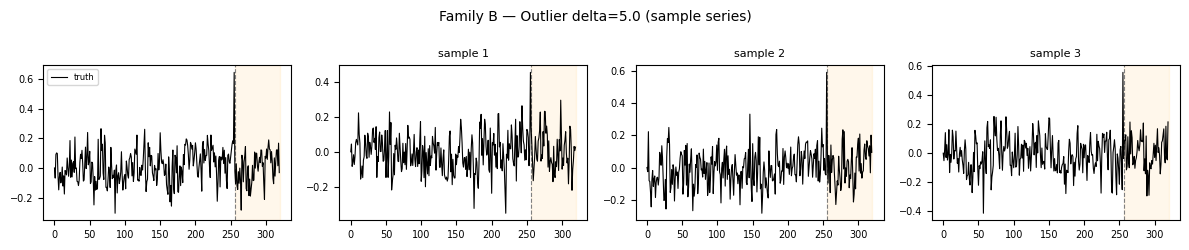

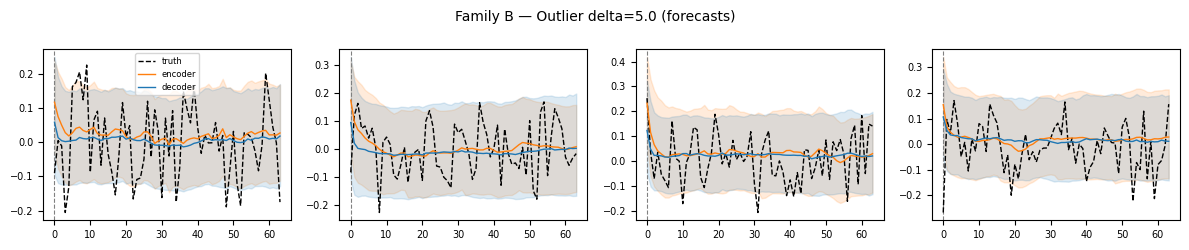

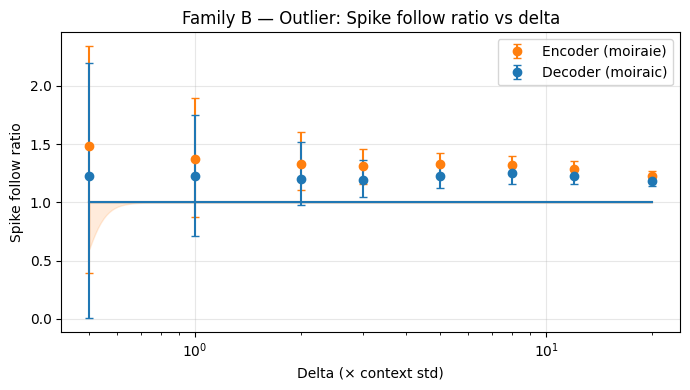

In [8]:
outlier_deltas = cfg['family_b']['outlier_deltas']
family = 'family_b_outlier'

enc_scores_all, dec_scores_all = [], []

for li, delta in enumerate(outlier_deltas):
    level_key = f'delta_{li:02d}'
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res, dec_res = get_forecasts(family, level_key)

    enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
    dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

    enc_scores_all.append(M.spike_follow_ratio(enc_med, meta))
    dec_scores_all.append(M.spike_follow_ratio(dec_med, meta))

    if li == len(outlier_deltas) // 2:
        si_list = sample_idxs(len(series))
        sample_series = series[si_list]
        sample_enc, sample_dec = enc_res, dec_res
        sample_delta = delta

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 3, 2.5))
fig.suptitle(f'Family B — Outlier delta={sample_delta:.1f} (sample series)', fontsize=10)
plot_series_panel(axes, sample_series)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 3, 2.5))
fig.suptitle(f'Family B — Outlier delta={sample_delta:.1f} (forecasts)', fontsize=10)
plot_forecast_panel(axes, sample_series, sample_enc, sample_dec, np.arange(N_SAMPLES))
plt.tight_layout(); plt.show()

enc_meds = np.array([M.aggregate_level(s)[0] for s in enc_scores_all])
dec_meds = np.array([M.aggregate_level(s)[0] for s in dec_scores_all])
enc_fit = bootstrap_sigmoid(np.array(outlier_deltas), enc_meds)
dec_fit = bootstrap_sigmoid(np.array(outlier_deltas), dec_meds)

fig = plot_response_curve(
    x_vals=outlier_deltas,
    encoder_scores=np.array(enc_scores_all),
    decoder_scores=np.array(dec_scores_all),
    encoder_fit=enc_fit, decoder_fit=dec_fit,
    xlabel='Delta (× context std)', ylabel='Spike follow ratio',
    title='Family B — Outlier: Spike follow ratio vs delta',
    log_x=True,
)
plt.show()

for model_name, fit in [('moiraie', enc_fit), ('moiraic', dec_fit)]:
    summary_rows.append(dict(
        model=model_name, family='family_b_outlier', carrier='outlier',
        x_star=fit['x_star'], x_star_lo=fit['x_star_ci'][0], x_star_hi=fit['x_star_ci'][1],
        beta=fit['beta'], beta_lo=fit['beta_ci'][0], beta_hi=fit['beta_ci'][1],
        r2=fit['r2'],
    ))

---
## Family B — Triangle wave (overshoot)

[16, 24, 32]


NameError: name 'sample_P' is not defined

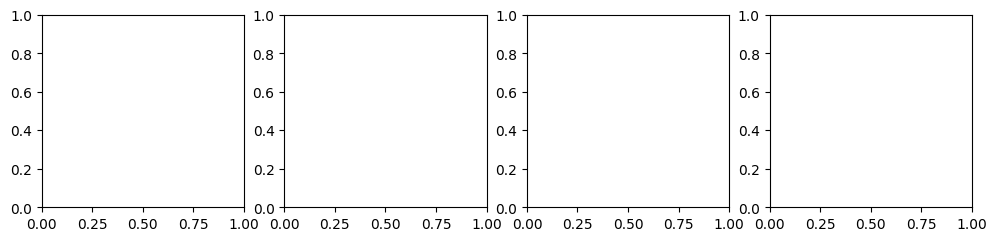

In [9]:
triangle_periods = cfg['family_b']['triangle_period_bins'] # [7, 10, 12, 16, 20, 24, 30, 31, 32, 48]
print(triangle_periods)
family = 'family_b_triangle'

tri_bins_plot = 7

enc_scores_all, dec_scores_all = [], []

for li, P in enumerate(triangle_periods):
    level_key = f'period_{li:02d}'
    series, meta, _ = load_stress_dataset(DATA_DIR, family, level_key)
    enc_res, dec_res = get_forecasts(family, level_key)

    enc_med = enc_res['forecast_quantiles'][:, MED_IDX, :]
    dec_med = dec_res['forecast_quantiles'][:, MED_IDX, :]

    enc_scores_all.append(M.overshoot(enc_med, meta, cfg))
    dec_scores_all.append(M.overshoot(dec_med, meta, cfg))

    if P == tri_bins_plot:
        si_list = sample_idxs(len(series))
        sample_series = series[si_list]
        sample_enc, sample_dec = enc_res, dec_res
        sample_P = P

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 3, 2.5))
fig.suptitle(f'Family B — Triangle P={sample_P} (sample series)', fontsize=10)
plot_series_panel(axes, sample_series)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 3, 2.5))
fig.suptitle(f'Family B — Triangle P={sample_P} (forecasts)', fontsize=10)
plot_forecast_panel(axes, sample_series, sample_enc, sample_dec, si_list)
plt.tight_layout(); plt.show()

# Bar plot: overshoot per triangle period
fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(len(triangle_periods))
enc_meds = [M.aggregate_level(s)[0] for s in enc_scores_all]
dec_meds = [M.aggregate_level(s)[0] for s in dec_scores_all]
ax.bar(x - 0.2, enc_meds, 0.4, label='encoder', color=ENC_COLOR)
ax.bar(x + 0.2, dec_meds, 0.4, label='decoder', color=DEC_COLOR)
ax.set_xticks(x)
ax.set_xticklabels([f'P={p}' for p in triangle_periods])
ax.set_ylabel('Overshoot (post-apex mean error)')
ax.set_title('Family B — Triangle: overshoot past apex')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---
## Summary table

In [ ]:
import pandas as pd

summary_path = os.path.join(SUMMARY_DIR, 'summary.csv')
make_summary_csv(summary_rows, summary_path)
print(f'Saved: {summary_path}')

df = pd.DataFrame(summary_rows)
df = df.round(3)
display(df)

Saved: /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block2_stress/results/curves/summary.csv


,model,family,carrier,x_star,x_star_lo,x_star_hi,beta,beta_lo,beta_hi,r2
0,moiraie,family_a_periodic,periodic,0.201,0.152,0.262,0.934,0.749,1.229,0.969
1,moiraic,family_a_periodic,periodic,0.194,0.148,0.253,1.153,0.830,1.520,0.972
2,moiraie,family_a_trend,trend,23735.221,13172.350,27994.433,1.853,1.520,2.048,-3.344
3,moiraic,family_a_trend,trend,23735.221,13172.350,27994.433,1.853,1.520,2.048,-3.344
4,moiraie,family_b_outlier,outlier,0.040,0.022,0.487,27.262,15.344,39.729,-23.285
5,moiraic,family_b_outlier,outlier,0.074,0.012,0.323,31.363,17.497,41.168,-108.001
